# Credit Card Default Prediction
## 01 - Exploratory Data Analysis (EDA)

This notebook performs a complete exploratory data analysis before preprocessing and model building.

## 1. Import Libraries

In [1]:
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.style.use("ggplot")
pd.set_option("display.max_columns", None)


## 2. Load Dataset
Update the path if required.

In [2]:
df = pd.read_csv("../data/raw/UCI_Credit_Card.csv")
df.head()

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
0,1,20000.0,2,2,1,24,2,2,-1,-1,-2,-2,3913.0,3102.0,689.0,0.0,0.0,0.0,0.0,689.0,0.0,0.0,0.0,0.0,1
1,2,120000.0,2,2,2,26,-1,2,0,0,0,2,2682.0,1725.0,2682.0,3272.0,3455.0,3261.0,0.0,1000.0,1000.0,1000.0,0.0,2000.0,1
2,3,90000.0,2,2,2,34,0,0,0,0,0,0,29239.0,14027.0,13559.0,14331.0,14948.0,15549.0,1518.0,1500.0,1000.0,1000.0,1000.0,5000.0,0
3,4,50000.0,2,2,1,37,0,0,0,0,0,0,46990.0,48233.0,49291.0,28314.0,28959.0,29547.0,2000.0,2019.0,1200.0,1100.0,1069.0,1000.0,0
4,5,50000.0,1,2,1,57,-1,0,-1,0,0,0,8617.0,5670.0,35835.0,20940.0,19146.0,19131.0,2000.0,36681.0,10000.0,9000.0,689.0,679.0,0


# Business Understanding

## Objective

Banks issue credit cards to customers and collect repayment information every month. The objective of this project is to predict whether a customer will default on their credit card payment in the following month using demographic information, billing history, repayment history, and payment records.

## Business Problem

Incorrectly identifying a high-risk customer may lead to financial losses, while incorrectly rejecting a trustworthy customer can reduce business opportunities. Therefore, building an accurate and interpretable credit risk model is important.

## Target Variable

- 0 → Customer did not default.
- 1 → Customer defaulted next month.


## 3. Random Sample

In [3]:
df.sample(5)

,ID,LIMIT_BAL,SEX,EDUCATION,MARRIAGE,AGE,PAY_0,PAY_2,PAY_3,PAY_4,PAY_5,PAY_6,BILL_AMT1,BILL_AMT2,BILL_AMT3,BILL_AMT4,BILL_AMT5,BILL_AMT6,PAY_AMT1,PAY_AMT2,PAY_AMT3,PAY_AMT4,PAY_AMT5,PAY_AMT6,default.payment.next.month
24421,24422,240000.0,1,2,1,34,0,0,0,0,0,0,242805.0,237854.0,240535.0,242770.0,191520.0,173461.0,10000.0,11000.0,9248.0,8005.0,8000.0,8000.0,0
27759,27760,50000.0,2,3,1,25,2,2,0,0,0,0,51243.0,49805.0,50654.0,41776.0,17083.0,9412.0,0.0,2025.0,2062.0,2016.0,1022.0,1388.0,1
13675,13676,240000.0,2,1,2,42,0,0,0,0,0,0,238107.0,242159.0,225695.0,210199.0,208307.0,203779.0,12067.0,10009.0,10000.0,10000.0,10000.0,30296.0,0
2589,2590,210000.0,2,2,1,35,2,2,2,0,0,2,61189.0,62721.0,61115.0,62334.0,66196.0,64979.0,3100.0,0.0,2235.0,4870.0,0.0,2563.0,1
19056,19057,30000.0,2,2,1,38,0,0,2,2,0,0,26664.0,29803.0,30766.0,29918.0,29071.0,29527.0,3582.0,1734.0,0.0,1148.0,1034.0,2667.0,0


## 4. Dataset Information

In [4]:
print("Shape:", df.shape)
display(df.info())
display(df.describe().T)


Shape: (30000, 25)
<class 'pandas.DataFrame'>
RangeIndex: 30000 entries, 0 to 29999
Data columns (total 25 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   ID                          30000 non-null  int64  
 1   LIMIT_BAL                   30000 non-null  float64
 2   SEX                         30000 non-null  int64  
 3   EDUCATION                   30000 non-null  int64  
 4   MARRIAGE                    30000 non-null  int64  
 5   AGE                         30000 non-null  int64  
 6   PAY_0                       30000 non-null  int64  
 7   PAY_2                       30000 non-null  int64  
 8   PAY_3                       30000 non-null  int64  
 9   PAY_4                       30000 non-null  int64  
 10  PAY_5                       30000 non-null  int64  
 11  PAY_6                       30000 non-null  int64  
 12  BILL_AMT1                   30000 non-null  float64
 13  BILL_AMT2              

None

,count,mean,std,min,25%,50%,75%,max
ID,30000.0,15000.500000,8660.398374,1.0,7500.75,15000.5,22500.25,30000.0
LIMIT_BAL,30000.0,167484.322667,129747.661567,10000.0,50000.00,140000.0,240000.00,1000000.0
SEX,30000.0,1.603733,0.489129,1.0,1.00,2.0,2.00,2.0
EDUCATION,30000.0,1.853133,0.790349,0.0,1.00,2.0,2.00,6.0
MARRIAGE,30000.0,1.551867,0.521970,0.0,1.00,2.0,2.00,3.0
AGE,30000.0,35.485500,9.217904,21.0,28.00,34.0,41.00,79.0
PAY_0,30000.0,-0.016700,1.123802,-2.0,-1.00,0.0,0.00,8.0
PAY_2,30000.0,-0.133767,1.197186,-2.0,-1.00,0.0,0.00,8.0
PAY_3,30000.0,-0.166200,1.196868,-2.0,-1.00,0.0,0.00,8.0
PAY_4,30000.0,-0.220667,1.169139,-2.0,-1.00,0.0,0.00,8.0


## 5. Missing Values

In [5]:
missing = pd.DataFrame({
    "Missing": df.isnull().sum(),
    "Percent": (df.isnull().sum()/len(df))*100
})
display(missing)


,Missing,Percent
ID,0,0.0
LIMIT_BAL,0,0.0
SEX,0,0.0
EDUCATION,0,0.0
MARRIAGE,0,0.0
AGE,0,0.0
PAY_0,0,0.0
PAY_2,0,0.0
PAY_3,0,0.0
PAY_4,0,0.0


## 6. Duplicate Rows

In [6]:
print("Duplicate Rows:", df.duplicated().sum())

Duplicate Rows: 0


## 7. Rename Target

In [7]:
df.rename(columns={"default.payment.next.month":"Default"}, inplace=True)
df.columns

Index(['ID', 'LIMIT_BAL', 'SEX', 'EDUCATION', 'MARRIAGE', 'AGE', 'PAY_0',
       'PAY_2', 'PAY_3', 'PAY_4', 'PAY_5', 'PAY_6', 'BILL_AMT1', 'BILL_AMT2',
       'BILL_AMT3', 'BILL_AMT4', 'BILL_AMT5', 'BILL_AMT6', 'PAY_AMT1',
       'PAY_AMT2', 'PAY_AMT3', 'PAY_AMT4', 'PAY_AMT5', 'PAY_AMT6', 'Default'],
      dtype='str')

## 8. Feature Categories

In [8]:
numerical_cols = [
"LIMIT_BAL","AGE",
"BILL_AMT1","BILL_AMT2","BILL_AMT3",
"BILL_AMT4","BILL_AMT5","BILL_AMT6",
"PAY_AMT1","PAY_AMT2","PAY_AMT3",
"PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

categorical_cols=["SEX","EDUCATION","MARRIAGE"]

pay_cols=["PAY_0","PAY_2","PAY_3","PAY_4","PAY_5","PAY_6"]


## 9. Target Distribution

Default
0    23364
1     6636
Name: count, dtype: int64

Default
0    77.88
1    22.12
Name: proportion, dtype: float64

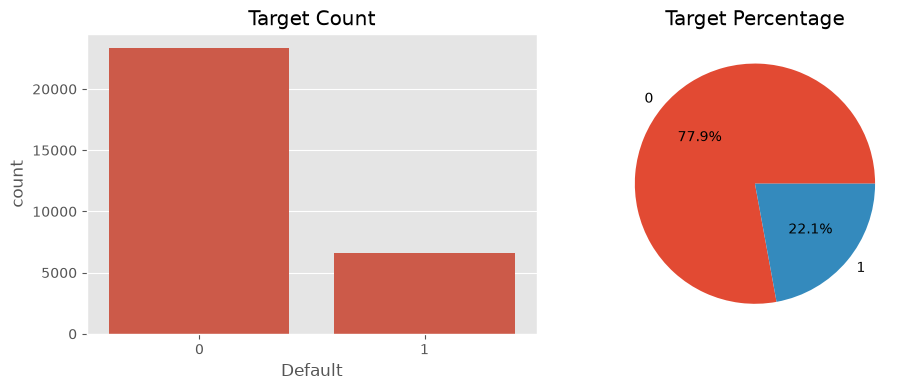

In [9]:
display(df["Default"].value_counts())
display(df["Default"].value_counts(normalize=True)*100)

fig,ax=plt.subplots(1,2,figsize=(10,4))
sns.countplot(data=df,x="Default",ax=ax[0])
ax[0].set_title("Target Count")
df["Default"].value_counts().plot.pie(autopct="%1.1f%%",ax=ax[1])
ax[1].set_ylabel("")
ax[1].set_title("Target Percentage")
plt.tight_layout()
plt.show()


## 10. Numerical Feature Distributions

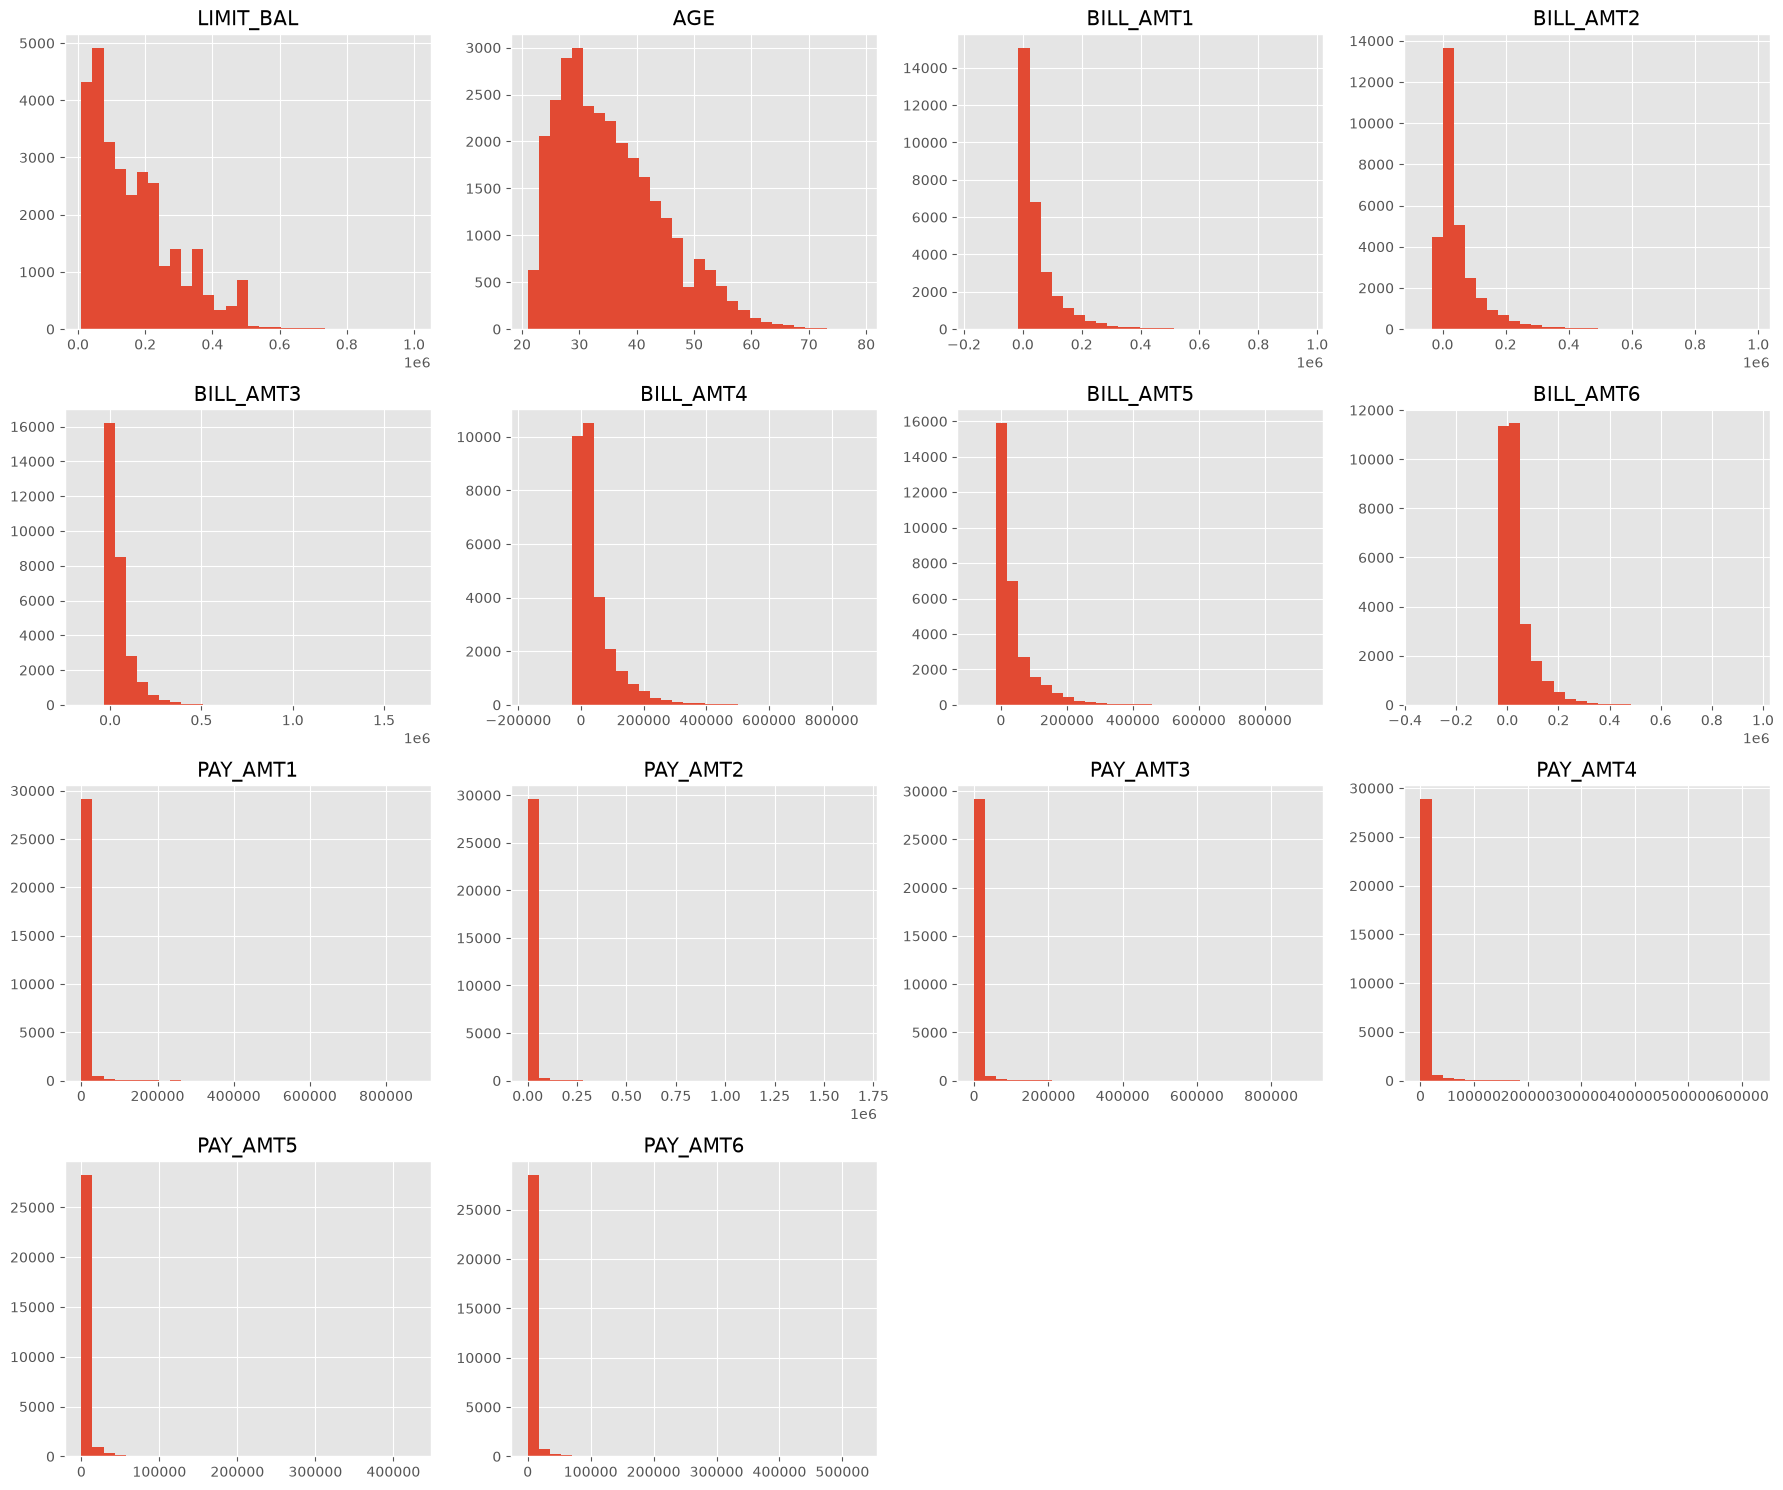

In [10]:
df[numerical_cols].hist(figsize=(18,15),bins=30)
plt.tight_layout()
plt.show()


## 11. Categorical Features

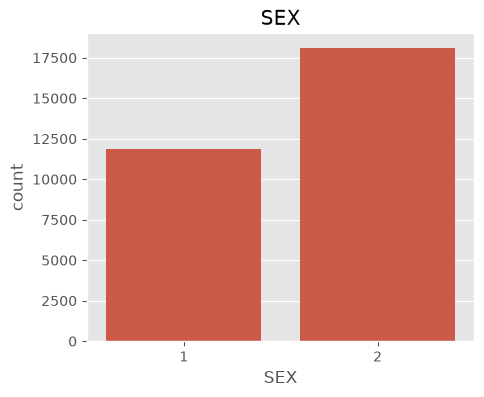

SEX
2    60.373333
1    39.626667
Name: Percent, dtype: float64

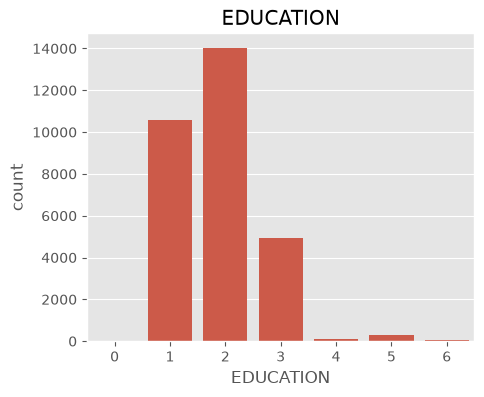

EDUCATION
2    46.766667
1    35.283333
3    16.390000
5     0.933333
4     0.410000
6     0.170000
0     0.046667
Name: Percent, dtype: float64

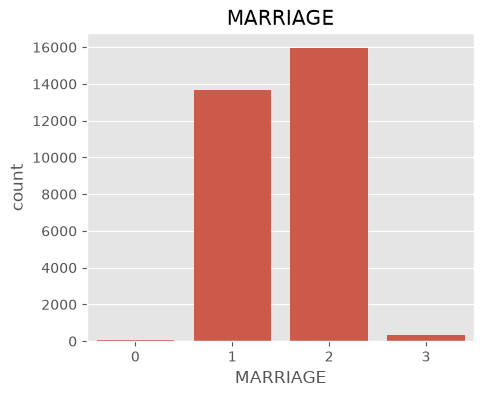

MARRIAGE
2    53.213333
1    45.530000
3     1.076667
0     0.180000
Name: Percent, dtype: float64

In [11]:
for col in categorical_cols:
    plt.figure(figsize=(5,4))
    sns.countplot(data=df,x=col)
    plt.title(col)
    plt.show()
    display((df[col].value_counts(normalize=True)*100).rename("Percent"))


## 12. Payment History

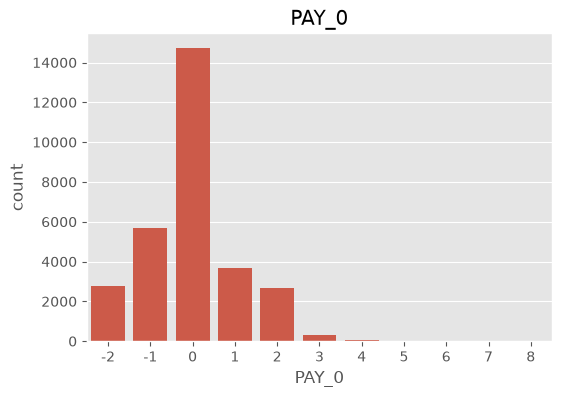

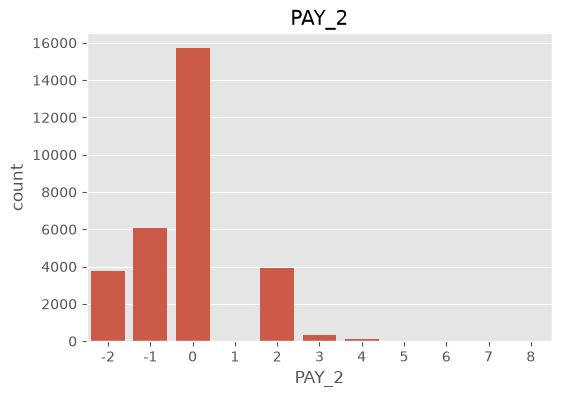

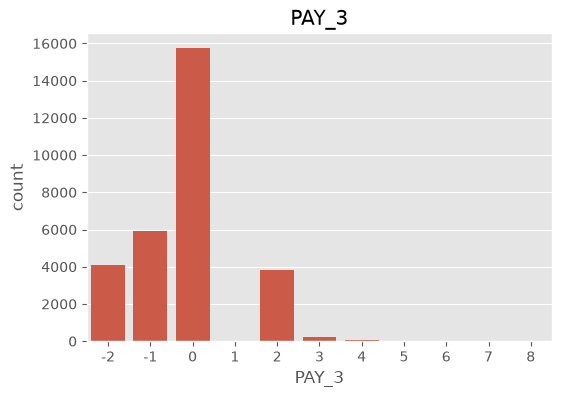

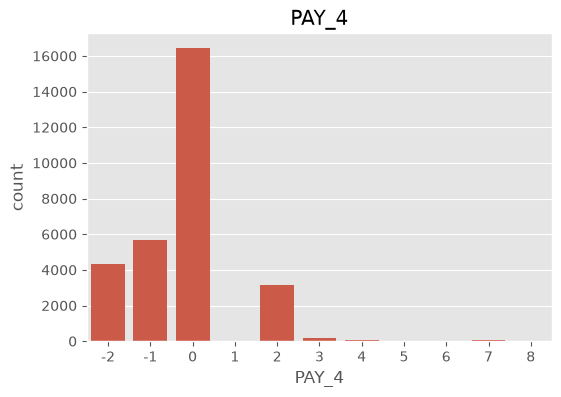

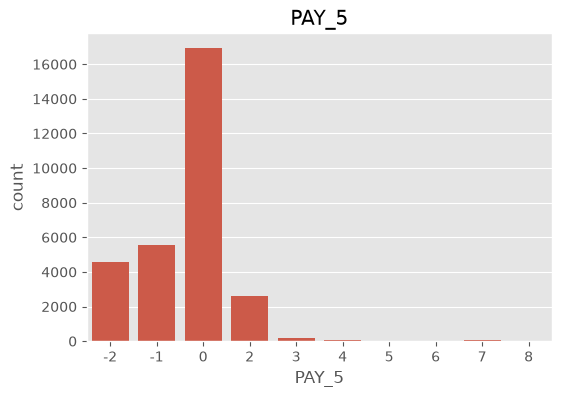

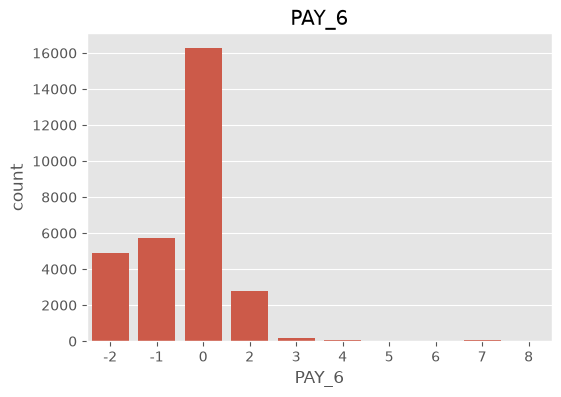

In [12]:
for col in pay_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df,x=col)
    plt.title(col)
    plt.show()


## 13. Skewness

In [13]:
skew = df[numerical_cols].skew().sort_values(ascending=False)
display(skew.to_frame("Skewness"))


,Skewness
PAY_AMT2,30.453817
PAY_AMT3,17.216635
PAY_AMT1,14.668364
PAY_AMT4,12.904985
PAY_AMT5,11.127417
PAY_AMT6,10.640727
BILL_AMT3,3.087830
BILL_AMT5,2.876380
BILL_AMT6,2.846645
BILL_AMT4,2.821965


## 14. Boxplots (Outlier Inspection)

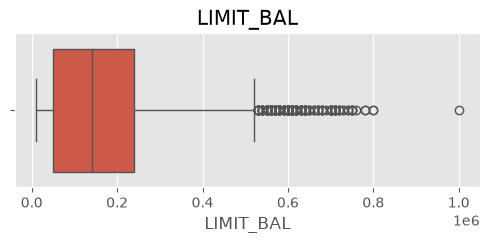

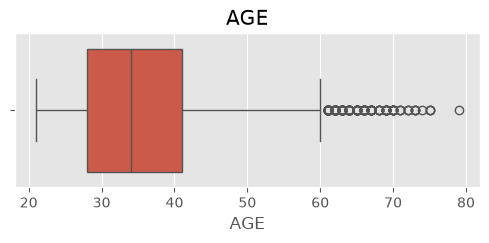

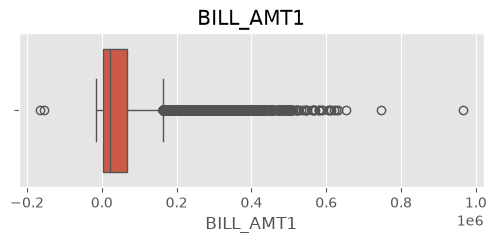

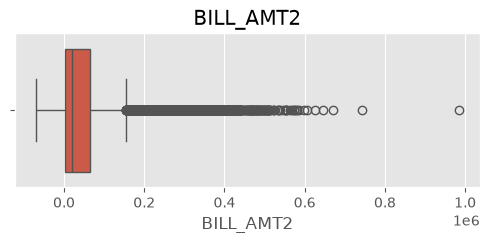

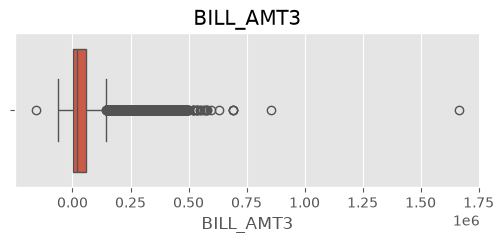

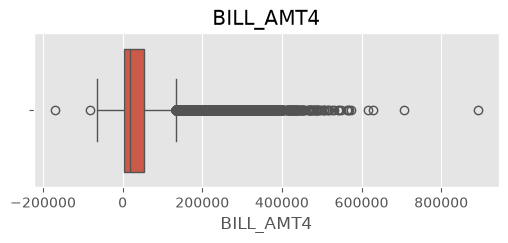

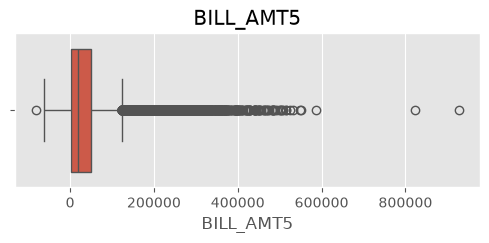

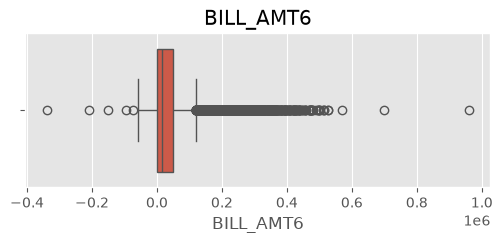

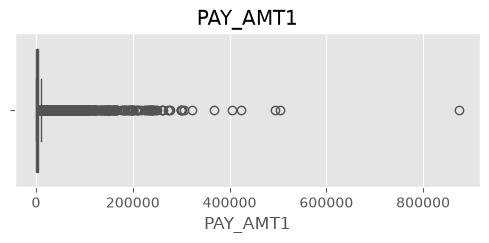

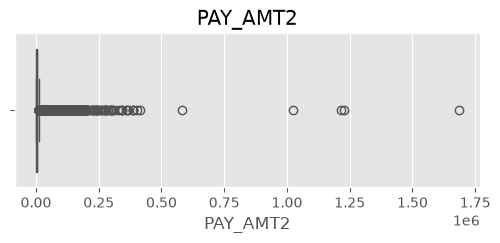

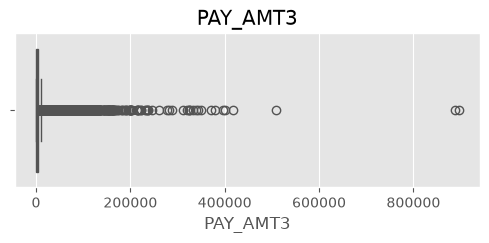

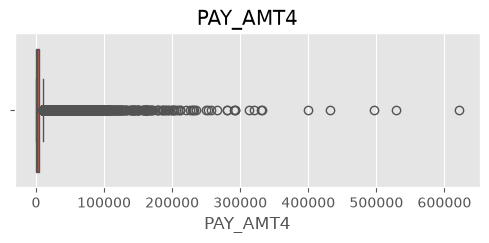

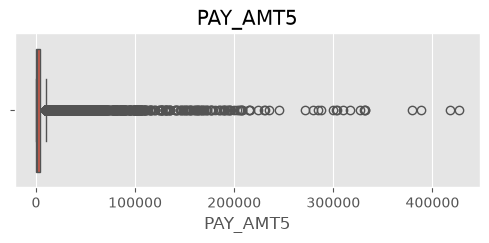

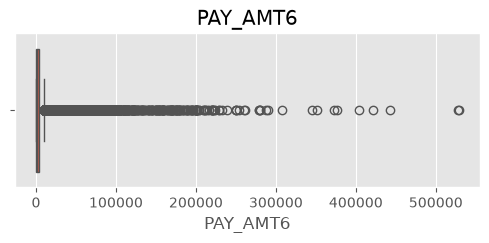

In [14]:
for col in numerical_cols:
    plt.figure(figsize=(6,2))
    sns.boxplot(x=df[col])
    plt.title(col)
    plt.show()


## 15. Default vs Categorical Features

Default,0,1
SEX,,
1,75.832773,24.167227
2,79.223719,20.776281


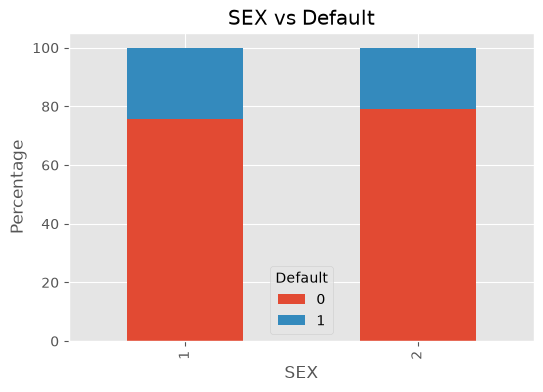

Default,0,1
EDUCATION,,
0,100.000000,0.000000
1,80.765234,19.234766
2,76.265146,23.734854
3,74.842384,25.157616
4,94.308943,5.691057
5,93.571429,6.428571
6,84.313725,15.686275


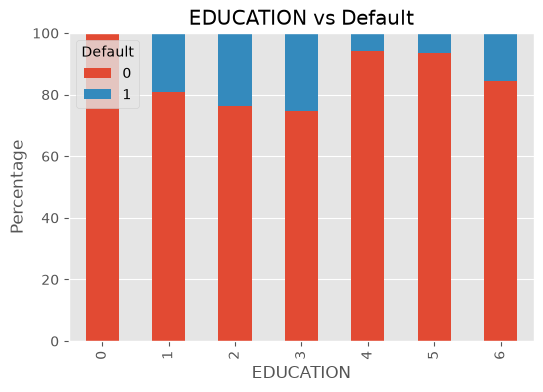

Default,0,1
MARRIAGE,,
0,90.740741,9.259259
1,76.528296,23.471704
2,79.071661,20.928339
3,73.993808,26.006192


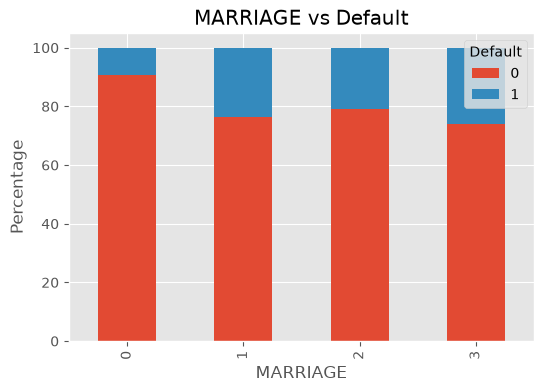

In [15]:
for col in categorical_cols:
    ct = pd.crosstab(df[col],df["Default"],normalize="index")*100
    display(ct)
    ct.plot(kind="bar",stacked=True,figsize=(6,4))
    plt.title(f"{col} vs Default")
    plt.ylabel("Percentage")
    plt.show()


## 16. Default vs Numerical Features

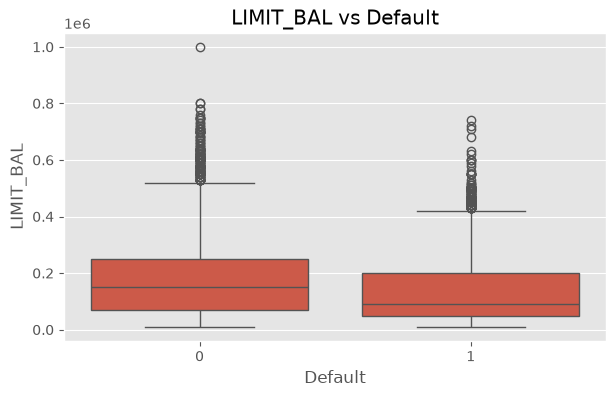

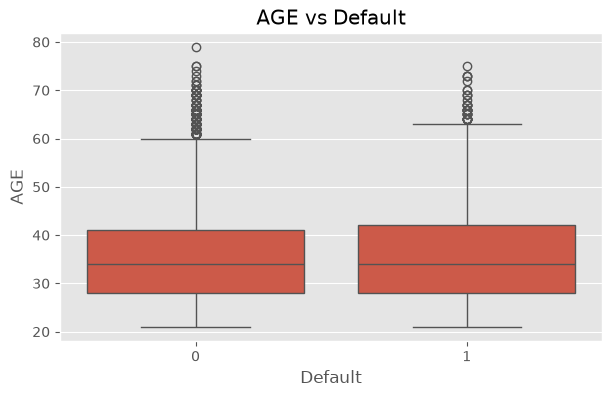

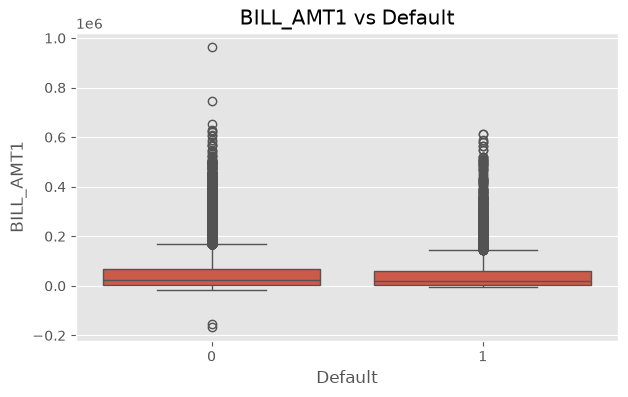

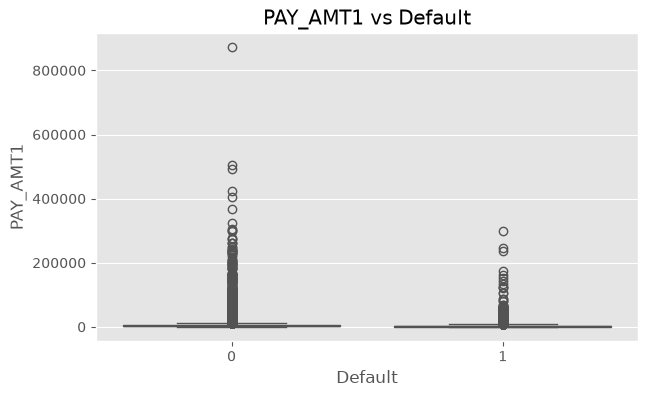

In [16]:
for col in ["LIMIT_BAL","AGE","BILL_AMT1","PAY_AMT1"]:
    plt.figure(figsize=(7,4))
    sns.boxplot(data=df,x="Default",y=col)
    plt.title(f"{col} vs Default")
    plt.show()


## 17. Payment History vs Default

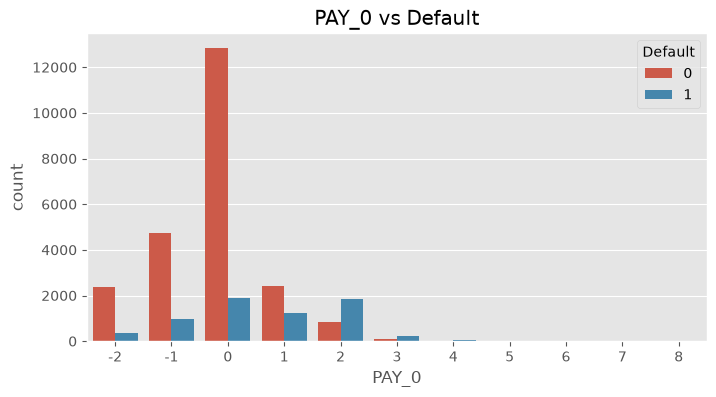

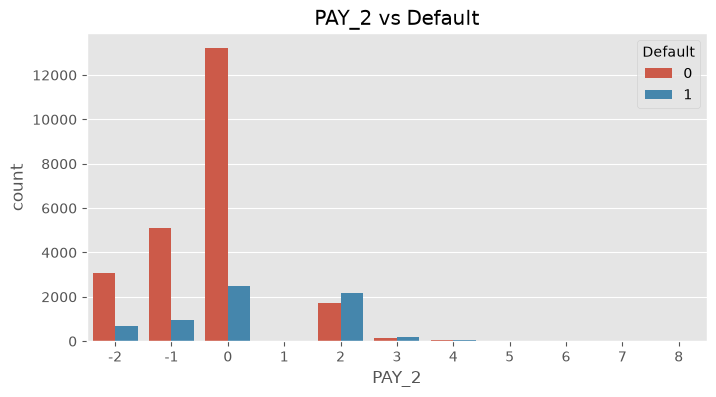

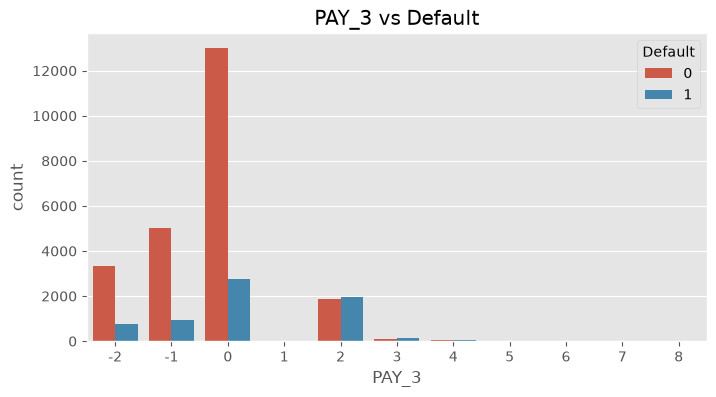

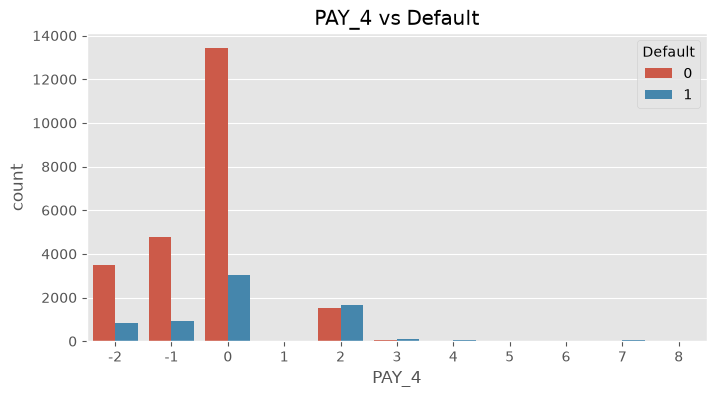

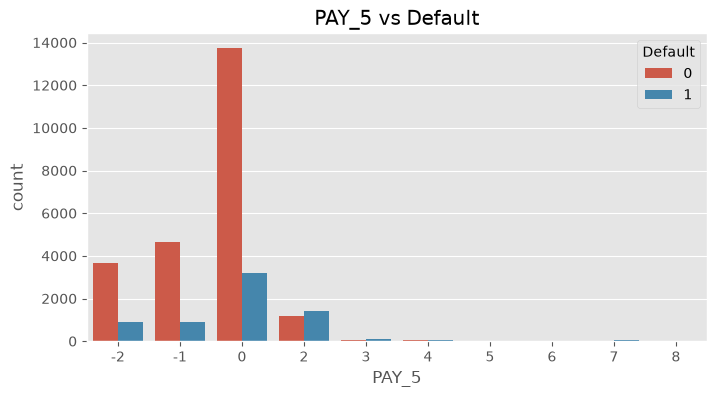

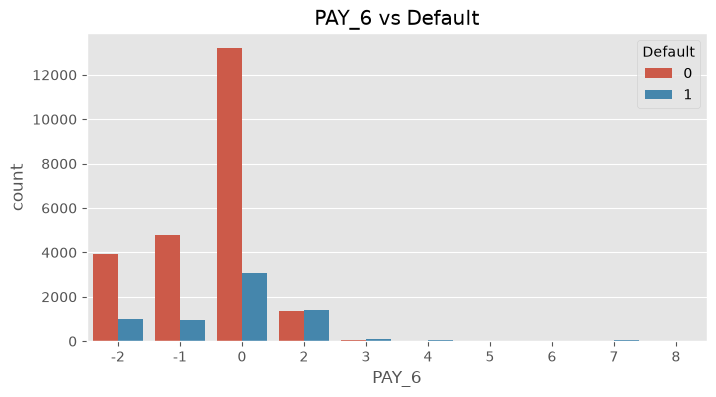

In [17]:
for col in pay_cols:
    plt.figure(figsize=(8,4))
    sns.countplot(data=df,x=col,hue="Default")
    plt.title(f"{col} vs Default")
    plt.show()


## 18. Correlation Heatmap

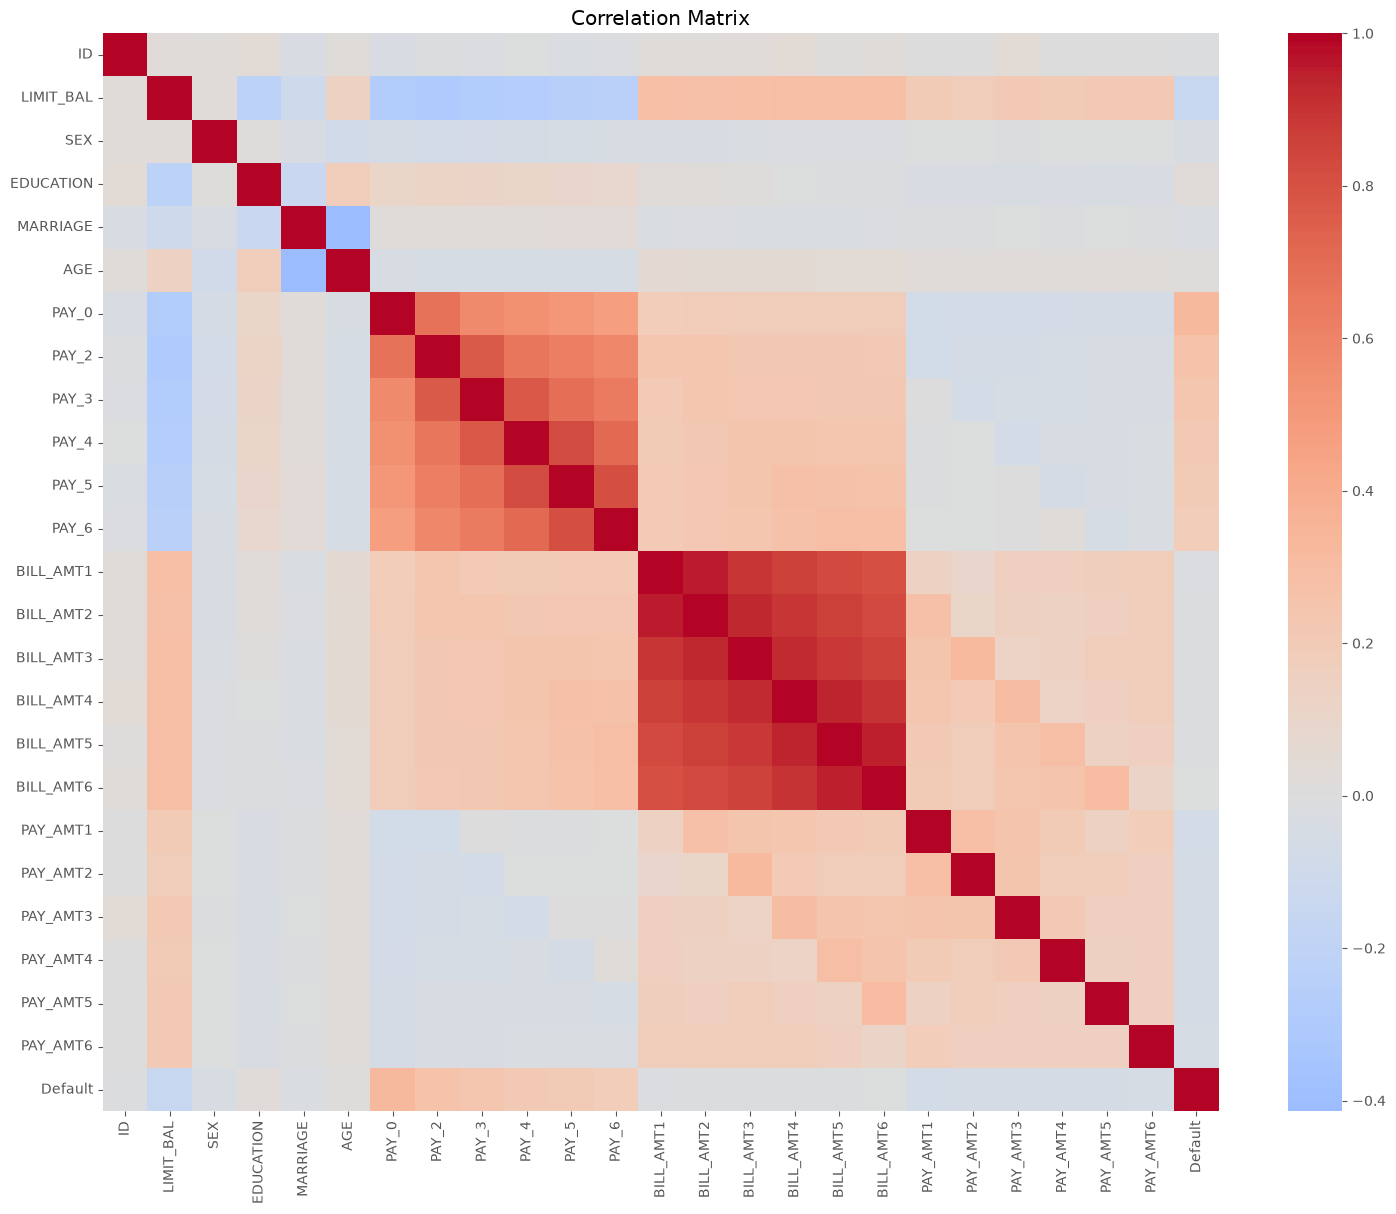

Default      1.000000
PAY_0        0.324794
PAY_2        0.263551
PAY_3        0.235253
PAY_4        0.216614
PAY_5        0.204149
PAY_6        0.186866
EDUCATION    0.028006
AGE          0.013890
BILL_AMT6   -0.005372
BILL_AMT5   -0.006760
BILL_AMT4   -0.010156
ID          -0.013952
BILL_AMT3   -0.014076
BILL_AMT2   -0.014193
BILL_AMT1   -0.019644
MARRIAGE    -0.024339
SEX         -0.039961
PAY_AMT6    -0.053183
PAY_AMT5    -0.055124
PAY_AMT3    -0.056250
PAY_AMT4    -0.056827
PAY_AMT2    -0.058579
PAY_AMT1    -0.072929
LIMIT_BAL   -0.153520
Name: Default, dtype: float64

In [18]:
plt.figure(figsize=(18,14))
corr=df.corr(numeric_only=True)
sns.heatmap(corr,cmap="coolwarm",center=0)
plt.title("Correlation Matrix")
plt.show()

corr_target = corr["Default"].sort_values(ascending=False)
display(corr_target)


In [19]:
df.drop(columns=["ID"], inplace=True)

In [20]:
df["EDUCATION"].value_counts().sort_index()

EDUCATION
0       14
1    10585
2    14030
3     4917
4      123
5      280
6       51
Name: count, dtype: int64

In [21]:
df["EDUCATION"] = df["EDUCATION"].replace({
    0:4,
    5:4,
    6:4
})
df["EDUCATION"].value_counts().sort_index()

EDUCATION
1    10585
2    14030
3     4917
4      468
Name: count, dtype: int64

In [22]:
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
0       54
1    13659
2    15964
3      323
Name: count, dtype: int64

In [23]:
df["MARRIAGE"] = df["MARRIAGE"].replace({
    0:3
})
df["MARRIAGE"].value_counts().sort_index()

MARRIAGE
1    13659
2    15964
3      377
Name: count, dtype: int64

In [24]:
df["SEX"].value_counts()

SEX
2    18112
1    11888
Name: count, dtype: int64

In [25]:
bill_cols = [
"BILL_AMT1","BILL_AMT2","BILL_AMT3",
"BILL_AMT4","BILL_AMT5","BILL_AMT6"
]

for col in bill_cols:
    print(col,(df[col]<0).sum())

BILL_AMT1 590
BILL_AMT2 669
BILL_AMT3 655
BILL_AMT4 675
BILL_AMT5 655
BILL_AMT6 688


In [26]:
pay_cols=[
"PAY_AMT1","PAY_AMT2","PAY_AMT3",
"PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

for col in pay_cols:
    print(col,(df[col]<0).sum())

PAY_AMT1 0
PAY_AMT2 0
PAY_AMT3 0
PAY_AMT4 0
PAY_AMT5 0
PAY_AMT6 0


In [27]:
status_cols=[
"PAY_0","PAY_2","PAY_3",
"PAY_4","PAY_5","PAY_6"
]

for col in status_cols:
    print(col)
    print(sorted(df[col].unique()))

PAY_0
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_2
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_3
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_4
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(1), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_5
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]
PAY_6
[np.int64(-2), np.int64(-1), np.int64(0), np.int64(2), np.int64(3), np.int64(4), np.int64(5), np.int64(6), np.int64(7), np.int64(8)]


In [28]:
df.to_csv(
    "../data/processed/clean_credit_data.csv",
    index=False
)

In [29]:
bill_cols = [
    "BILL_AMT1", "BILL_AMT2", "BILL_AMT3",
    "BILL_AMT4", "BILL_AMT5", "BILL_AMT6"
]

for i, col in enumerate(bill_cols, start=1):
    df[f"UTILIZATION_{i}"] = df[col] / df["LIMIT_BAL"]


util_cols = [f"UTILIZATION_{i}" for i in range(1,7)]

df["AVG_UTILIZATION"] = df[util_cols].mean(axis=1)
df["MAX_UTILIZATION"] = df[util_cols].max(axis=1)
df["MIN_UTILIZATION"] = df[util_cols].min(axis=1)
df["UTILIZATION_STD"] = df[util_cols].std(axis=1)


In [30]:
df[[
    "AVG_UTILIZATION",
    "MAX_UTILIZATION",
    "MIN_UTILIZATION",
    "UTILIZATION_STD"
]].describe()

,AVG_UTILIZATION,MAX_UTILIZATION,MIN_UTILIZATION,UTILIZATION_STD
count,30000.000000,30000.000000,30000.000000,30000.000000
mean,0.373048,0.494965,0.260954,0.098433
std,0.351890,0.433046,0.316714,0.131079
min,-0.232590,-0.100000,-1.509530,0.000000
25%,0.029997,0.070636,0.000000,0.014405
50%,0.284834,0.430702,0.088090,0.041489
75%,0.687929,0.923246,0.495669,0.135681
max,5.364308,10.688575,3.885550,4.230420


In [31]:
df[[
    "AVG_UTILIZATION",
    "MAX_UTILIZATION",
    "MIN_UTILIZATION",
    "UTILIZATION_STD",
    "Default"
]].head()

,AVG_UTILIZATION,MAX_UTILIZATION,MIN_UTILIZATION,UTILIZATION_STD,Default
0,0.064200,0.195650,0.000000,0.088082,1
1,0.023718,0.028792,0.014375,0.005316,1
2,0.188246,0.324878,0.150656,0.067384,0
3,0.771113,0.985820,0.566280,0.211316,0
4,0.364463,0.716700,0.113400,0.213372,0


In [32]:
bill_cols = [
    "BILL_AMT1","BILL_AMT2","BILL_AMT3",
    "BILL_AMT4","BILL_AMT5","BILL_AMT6"
]

payment_cols = [
    "PAY_AMT1","PAY_AMT2","PAY_AMT3",
    "PAY_AMT4","PAY_AMT5","PAY_AMT6"
]

for i in range(6):
    df[f"PAY_RATIO_{i+1}"] = np.where(
        df[bill_cols[i]] > 0,
        df[payment_cols[i]] / df[bill_cols[i]],
        0
    )


ratio_cols = [f"PAY_RATIO_{i}" for i in range(1,7)]

df["AVG_PAYMENT_RATIO"] = df[ratio_cols].mean(axis=1)
df["MAX_PAYMENT_RATIO"] = df[ratio_cols].max(axis=1)
df["MIN_PAYMENT_RATIO"] = df[ratio_cols].min(axis=1)
df["PAYMENT_RATIO_STD"] = df[ratio_cols].std(axis=1)

df["AVG_PAYMENT"] = df[payment_cols].mean(axis=1)

df["AVG_BILL"] = df[bill_cols].mean(axis=1)

for i in range(6):
    df[f"OUTSTANDING_{i+1}"] = (
        df[bill_cols[i]] -
        df[payment_cols[i]]
    )

out_cols = [f"OUTSTANDING_{i}" for i in range(1,7)]

df["AVG_OUTSTANDING"] = df[out_cols].mean(axis=1)

df["MAX_OUTSTANDING"] = df[out_cols].max(axis=1)




In [33]:
pay_status_cols = [
    "PAY_0",
    "PAY_2",
    "PAY_3",
    "PAY_4",
    "PAY_5",
    "PAY_6"
]
df["AVG_DELAY"] = df[pay_status_cols].mean(axis=1)
df["MAX_DELAY"] = df[pay_status_cols].max(axis=1)
df["MIN_DELAY"] = df[pay_status_cols].min(axis=1)
df["DELAY_STD"] = df[pay_status_cols].std(axis=1)

df["LATE_PAYMENT_COUNT"] = (df[pay_status_cols] > 0).sum(axis=1)
df["SERIOUS_DELAY_COUNT"] = (df[pay_status_cols] >= 2).sum(axis=1)
df["ON_TIME_COUNT"] = (df[pay_status_cols] <= 0).sum(axis=1)



In [34]:
delay_features = [
    "AVG_DELAY",
    "MAX_DELAY",
    "MIN_DELAY",
    "DELAY_STD",
    "LATE_PAYMENT_COUNT",
    "SERIOUS_DELAY_COUNT",
    "ON_TIME_COUNT"
]

df[delay_features].describe()
df[delay_features + ["Default"]].head(10)

,AVG_DELAY,MAX_DELAY,MIN_DELAY,DELAY_STD,LATE_PAYMENT_COUNT,SERIOUS_DELAY_COUNT,ON_TIME_COUNT,Default
0,-0.333333,2,-2,1.861899,2,2,4,1
1,0.500000,2,-1,1.224745,2,2,4,1
2,0.000000,0,0,0.000000,0,0,6,0
3,0.000000,0,0,0.000000,0,0,6,0
4,-0.333333,0,-1,0.516398,0,0,6,0
5,0.000000,0,0,0.000000,0,0,6,0
6,0.000000,0,0,0.000000,0,0,6,0
7,-0.500000,0,-1,0.547723,0,0,6,0
8,0.333333,2,0,0.816497,1,1,5,0
9,-1.666667,-1,-2,0.516398,0,0,6,0


In [35]:
df["BILL_TREND"] = df["BILL_AMT1"] - df["BILL_AMT6"]
df["PAYMENT_TREND"] = df["PAY_AMT1"] - df["PAY_AMT6"]

df["RECENT_AVG_BILL"] = (
    df["BILL_AMT1"] +
    df["BILL_AMT2"] +
    df["BILL_AMT3"]
) / 3
df["OLDER_AVG_BILL"] = (
    df["BILL_AMT4"] +
    df["BILL_AMT5"] +
    df["BILL_AMT6"]
) / 3
df["RECENT_AVG_PAYMENT"] = (
    df["PAY_AMT1"] +
    df["PAY_AMT2"] +
    df["PAY_AMT3"]
) / 3
df["OLDER_AVG_PAYMENT"] = (
    df["PAY_AMT4"] +
    df["PAY_AMT5"] +
    df["PAY_AMT6"]
) / 3


In [36]:
df["AVG_BILL_TO_LIMIT"] = (
    (df["RECENT_AVG_BILL"] + df["OLDER_AVG_BILL"] ) /
    df["LIMIT_BAL"]
)
df["AVG_PAYMENT_TO_LIMIT"] = (
    (df["RECENT_AVG_PAYMENT"] + df["OLDER_AVG_PAYMENT"] ) /
    df["LIMIT_BAL"]
)

print(f"Original Features : 24")
print(f"Current Features  : {df.shape[1]}")
print(f"New Features      : {df.shape[1]-24}")


Original Features : 24
Current Features  : 69
New Features      : 45


In [37]:
df.isnull().sum().sort_values(ascending=False).head(20)

LIMIT_BAL    0
SEX          0
EDUCATION    0
MARRIAGE     0
AGE          0
PAY_0        0
PAY_2        0
PAY_3        0
PAY_4        0
PAY_5        0
PAY_6        0
BILL_AMT1    0
BILL_AMT2    0
BILL_AMT3    0
BILL_AMT4    0
BILL_AMT5    0
BILL_AMT6    0
PAY_AMT1     0
PAY_AMT2     0
PAY_AMT3     0
dtype: int64

In [38]:
import numpy as np

np.isinf(df.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [39]:
corr = df.corr(numeric_only=True)["Default"].sort_values()

corr

ON_TIME_COUNT         -0.398394
LIMIT_BAL             -0.153520
AVG_PAYMENT           -0.102354
RECENT_AVG_PAYMENT    -0.086592
OLDER_AVG_PAYMENT     -0.083054
                         ...   
PAY_0                  0.324794
MAX_DELAY              0.331036
LATE_PAYMENT_COUNT     0.398394
SERIOUS_DELAY_COUNT    0.398873
Default                1.000000
Name: Default, Length: 69, dtype: float64

In [40]:
corr.abs().sort_values(ascending=False).head(25)

Default                1.000000
SERIOUS_DELAY_COUNT    0.398873
LATE_PAYMENT_COUNT     0.398394
ON_TIME_COUNT          0.398394
MAX_DELAY              0.331036
PAY_0                  0.324794
AVG_DELAY              0.281955
PAY_2                  0.263551
DELAY_STD              0.248922
PAY_3                  0.235253
PAY_4                  0.216614
PAY_5                  0.204149
PAY_6                  0.186866
MIN_DELAY              0.167148
LIMIT_BAL              0.153520
MIN_UTILIZATION        0.129448
UTILIZATION_6          0.123373
UTILIZATION_5          0.119156
UTILIZATION_4          0.115925
AVG_BILL_TO_LIMIT      0.115483
AVG_UTILIZATION        0.115483
UTILIZATION_3          0.103902
AVG_PAYMENT            0.102354
UTILIZATION_2          0.099039
RECENT_AVG_PAYMENT     0.086592
Name: Default, dtype: float64

In [41]:
corr_matrix = df.corr(numeric_only=True).abs()

upper = corr_matrix.where(
    np.triu(np.ones(corr_matrix.shape), k=1).astype(bool)
)

high_corr = [
    column
    for column in upper.columns
    if any(upper[column] > 0.95)
]

high_corr

['BILL_AMT2',
 'PAYMENT_RATIO_STD',
 'AVG_BILL',
 'OUTSTANDING_1',
 'OUTSTANDING_3',
 'OUTSTANDING_4',
 'OUTSTANDING_5',
 'OUTSTANDING_6',
 'AVG_OUTSTANDING',
 'SERIOUS_DELAY_COUNT',
 'ON_TIME_COUNT',
 'RECENT_AVG_BILL',
 'OLDER_AVG_BILL',
 'AVG_BILL_TO_LIMIT']

In [42]:
df.to_csv(
    "../data/processed/feature_engineered_credit_data.csv",
    index=False
)

In [43]:
print(df.shape)

(30000, 69)


In [44]:
df.isnull().sum().sum()

np.int64(0)

In [45]:
np.isinf(df.select_dtypes(include=np.number)).sum().sum()

np.int64(0)

In [46]:
corr = df.corr(numeric_only=True)["Default"].sort_values(key=abs, ascending=False)
corr.head(20)

Default                1.000000
SERIOUS_DELAY_COUNT    0.398873
LATE_PAYMENT_COUNT     0.398394
ON_TIME_COUNT         -0.398394
MAX_DELAY              0.331036
PAY_0                  0.324794
AVG_DELAY              0.281955
PAY_2                  0.263551
DELAY_STD              0.248922
PAY_3                  0.235253
PAY_4                  0.216614
PAY_5                  0.204149
PAY_6                  0.186866
MIN_DELAY              0.167148
LIMIT_BAL             -0.153520
MIN_UTILIZATION        0.129448
UTILIZATION_6          0.123373
UTILIZATION_5          0.119156
UTILIZATION_4          0.115925
AVG_BILL_TO_LIMIT      0.115483
Name: Default, dtype: float64